In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

Saving retail_price.csv to retail_price.csv


In [6]:
import pandas as pd
import io

df = pd.read_csv(io.BytesIO(uploaded['retail_price.csv']))
print(df.head())  # Display the first few rows

  product_id product_category_name  month_year  qty  total_price  \
0       bed1        bed_bath_table  01-05-2017    1        45.95   
1       bed1        bed_bath_table  01-06-2017    3       137.85   
2       bed1        bed_bath_table  01-07-2017    6       275.70   
3       bed1        bed_bath_table  01-08-2017    4       183.80   
4       bed1        bed_bath_table  01-09-2017    2        91.90   

   freight_price  unit_price  product_name_lenght  product_description_lenght  \
0      15.100000       45.95                   39                         161   
1      12.933333       45.95                   39                         161   
2      14.840000       45.95                   39                         161   
3      14.287500       45.95                   39                         161   
4      15.100000       45.95                   39                         161   

   product_photos_qty  ...  comp_1  ps1        fp1      comp_2  ps2  \
0                   2  ...    89.

In [7]:
# Check for missing values
print(df.isnull().sum())

# Drop rows with missing critical fields
df.dropna(subset=['qty', 'unit_price', 'total_price', 'freight_price', 'comp_1', 'comp_2', 'comp_3'], inplace=True)

# Estimate Cost of Goods Sold (COGS) as a proxy: unit_price - avg competitor price
df['avg_comp_price'] = df[['comp_1', 'comp_2', 'comp_3']].mean(axis=1)
df['estimated_margin'] = df['unit_price'] - df['avg_comp_price']
df['profit'] = df['qty'] * df['estimated_margin']

product_id                    0
product_category_name         0
month_year                    0
qty                           0
total_price                   0
freight_price                 0
unit_price                    0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_score                 0
customers                     0
weekday                       0
weekend                       0
holiday                       0
month                         0
year                          0
s                             0
volume                        0
comp_1                        0
ps1                           0
fp1                           0
comp_2                        0
ps2                           0
fp2                           0
comp_3                        0
ps3                           0
fp3                           0
lag_price                     0
dtype: int64


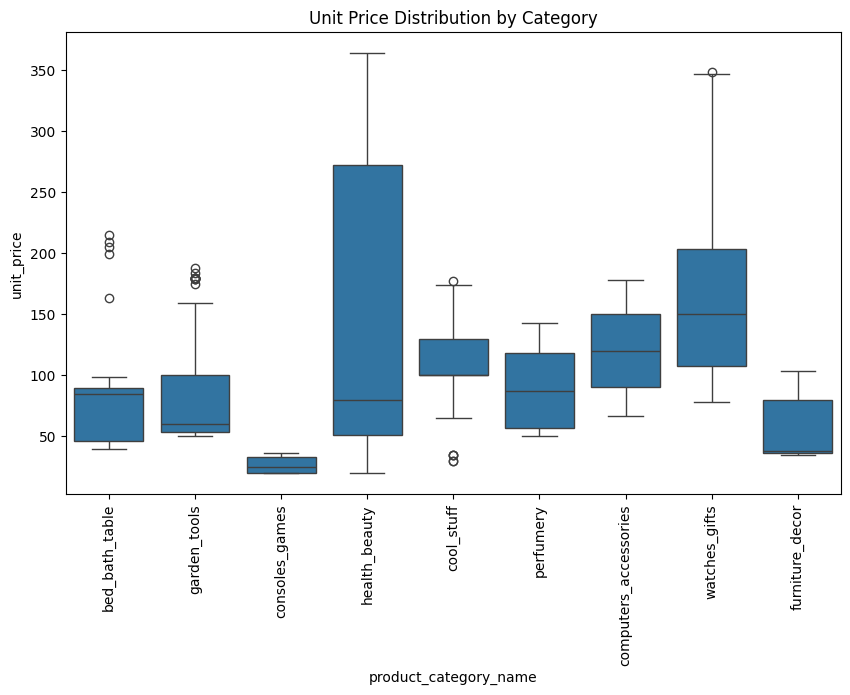

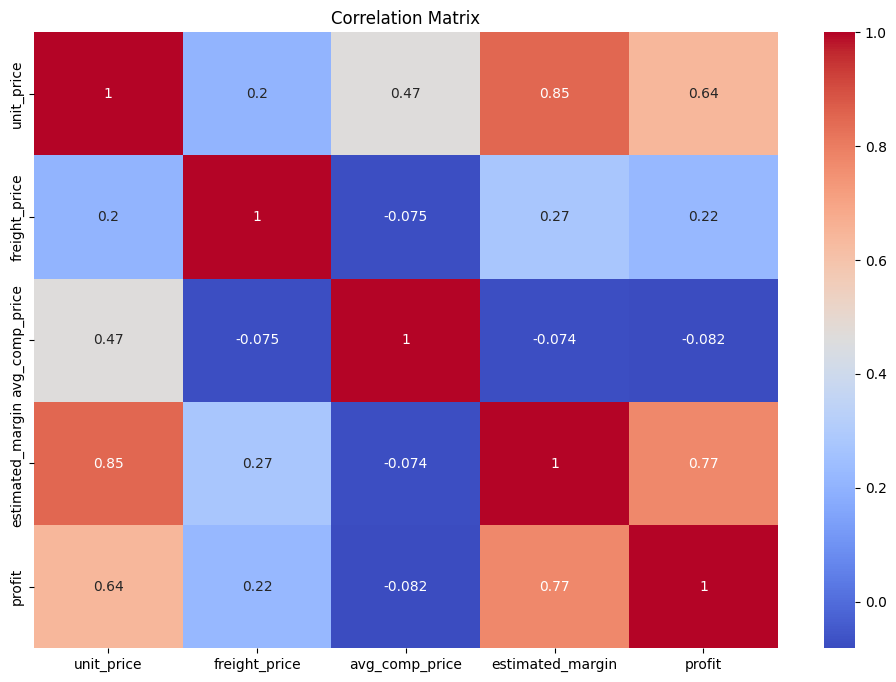

In [8]:
# Plot the distribution of unit prices by product category
plt.figure(figsize=(10, 6))
sns.boxplot(x='product_category_name', y='unit_price', data=df)
plt.xticks(rotation=90)
plt.title('Unit Price Distribution by Category')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df[['unit_price', 'freight_price', 'avg_comp_price', 'estimated_margin', 'profit']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

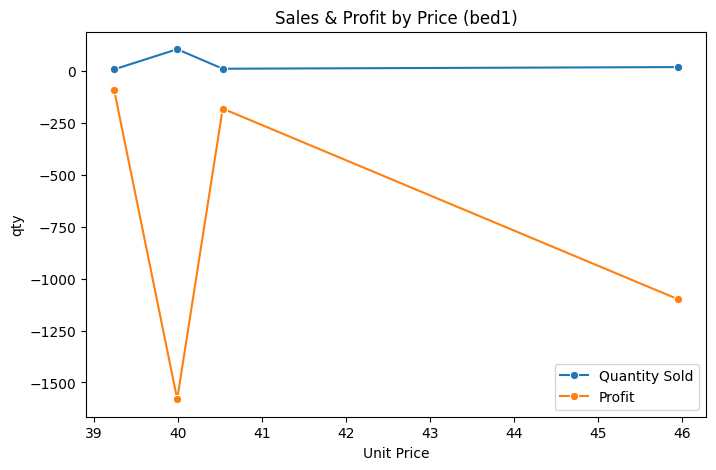

In [9]:
# Group by product and price to see aggregated performance
agg = df.groupby(['product_id', 'unit_price']).agg({
    'qty': 'sum',
    'profit': 'sum'
}).reset_index()

# Visualize sales volume vs price for a sample product
sample_product = agg[agg['product_id'] == 'bed1']
plt.figure(figsize=(8, 5))
sns.lineplot(x='unit_price', y='qty', data=sample_product, marker='o', label='Quantity Sold')
sns.lineplot(x='unit_price', y='profit', data=sample_product, marker='o', label='Profit')
plt.title('Sales & Profit by Price (bed1)')
plt.xlabel('Unit Price')
plt.legend()
plt.show()